In [18]:
"""
Hodgkin-Huxley Neuron Model
============================
Simulates the full HH equations as a dynamical system and plots the results.

State variables:
    V  : membrane potential (mV)
    m  : Na+ activation gate
    h  : Na+ inactivation gate
    n  : K+ activation gate

Parameters follow the original Hodgkin & Huxley (1952) conventions,
with voltage defined relative to resting potential (V_rest = 0 mV offset).
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# ---------------------------------------------------------------------------
# Rate functions (alpha / beta) for each gating variable
# All voltages in mV, rates in ms^-1
# ---------------------------------------------------------------------------

def alpha_m(V):
    """Na+ activation – opening rate."""
    dV = V + 40.0
    if abs(dV) < 1e-7:          # avoid 0/0 at V = -40 mV
        return 1.0
    return 0.1 * dV / (1.0 - np.exp(-dV / 10.0))

def beta_m(V):
    """Na+ activation – closing rate."""
    return 4.0 * np.exp(-(V + 65.0) / 18.0)

def alpha_h(V):
    """Na+ inactivation – opening rate."""
    return 0.07 * np.exp(-(V + 65.0) / 20.0)

def beta_h(V):
    """Na+ inactivation – closing rate."""
    return 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))

def alpha_n(V):
    """K+ activation – opening rate."""
    dV = V + 55.0
    if abs(dV) < 1e-7:          # avoid 0/0 at V = -55 mV
        return 0.1
    return 0.01 * dV / (1.0 - np.exp(-dV / 10.0))

def beta_n(V):
    """K+ activation – closing rate."""
    return 0.125 * np.exp(-(V + 65.0) / 80.0)


# Vectorised wrappers so the rate functions work element-wise on arrays
alpha_m = np.vectorize(alpha_m)
alpha_n = np.vectorize(alpha_n)


# ---------------------------------------------------------------------------
# Steady-state (infinity) values and time constants
# ---------------------------------------------------------------------------

def gate_inf(alpha, beta, V):
    """Steady-state open probability:  x_inf = alpha / (alpha + beta)."""
    a = alpha(V); b = beta(V)
    return a / (a + b)

def gate_tau(alpha, beta, V):
    """Time constant (ms):  tau = 1 / (alpha + beta)."""
    return 1.0 / (alpha(V) + beta(V))


# ---------------------------------------------------------------------------
# Hodgkin-Huxley ODE system
# ---------------------------------------------------------------------------

def hodgkin_huxley(t, y, I_ext, C_m, g_Na, g_K, g_L, E_Na, E_K, E_L):
    """
    Right-hand side of the HH equations.

    Parameters
    ----------
    t      : float  – current time (ms)
    y      : array  – [V, m, h, n]
    I_ext  : callable(t) or float – applied current (µA/cm²)
    C_m    : float  – membrane capacitance (µF/cm²)
    g_Na   : float  – max Na+ conductance  (mS/cm²)
    g_K    : float  – max K+  conductance  (mS/cm²)
    g_L    : float  – leak conductance     (mS/cm²)
    E_Na   : float  – Na+ reversal potential (mV)
    E_K    : float  – K+  reversal potential (mV)
    E_L    : float  – leak reversal potential (mV)

    Returns
    -------
    [dV/dt, dm/dt, dh/dt, dn/dt]
    """
    V, m, h, n = y

    # Applied current
    I = I_ext(t) if callable(I_ext) else float(I_ext)

    # Ionic currents  (mA/cm²  ≡  µA/cm² with consistent unit scaling)
    I_Na = g_Na * m**3 * h * (V - E_Na)
    I_K  = g_K  * n**4     * (V - E_K)
    I_L  = g_L             * (V - E_L)

    # Membrane voltage
    dV = (I - I_Na - I_K - I_L) / C_m

    # Gating variables  dx/dt = alpha*(1-x) - beta*x
    dm = alpha_m(V) * (1 - m) - beta_m(V) * m
    dh = alpha_h(V) * (1 - h) - beta_h(V) * h
    dn = alpha_n(V) * (1 - n) - beta_n(V) * n

    return [dV, dm, dh, dn]


# ---------------------------------------------------------------------------
# Convenience simulation wrapper
# ---------------------------------------------------------------------------

def simulate_hh(
    t_span=(0.0, 50.0),
    dt=0.01,
    I_ext=10.0,
    V0=-65.0,
    # Canonical HH parameters (Hodgkin & Huxley 1952)
    C_m=1.0,
    g_Na=120.0,
    g_K=36.0,
    g_L=0.3,
    E_Na=50.0,
    E_K=-77.0,
    E_L=-54.387,
):
    """
    Simulate the Hodgkin-Huxley model.

    Parameters
    ----------
    t_span : (t_start, t_end) in ms
    dt     : output time step (ms)
    I_ext  : applied current – float (constant µA/cm²) or callable(t)
    V0     : initial membrane potential (mV)
    ...    : biophysical parameters (defaults are canonical HH values)

    Returns
    -------
    t  : 1-D array of time points (ms)
    V  : membrane potential (mV)
    m  : Na+ activation gate
    h  : Na+ inactivation gate
    n  : K+  activation gate
    """
    # Initialise gating variables at steady state for V0
    m0 = gate_inf(alpha_m, beta_m, V0)
    h0 = gate_inf(alpha_h, beta_h, V0)
    n0 = gate_inf(alpha_n, beta_n, V0)
    y0 = [V0, m0, h0, n0]

    t_eval = np.arange(t_span[0], t_span[1], dt)

    sol = solve_ivp(
        hodgkin_huxley,
        t_span,
        y0,
        method="RK45",
        t_eval=t_eval,
        args=(I_ext, C_m, g_Na, g_K, g_L, E_Na, E_K, E_L),
        rtol=1e-6,
        atol=1e-8,
    )

    t = sol.t
    V, m, h, n = sol.y
    return t, V, m, h, n


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_hh(t, V, m, h, n, I_ext=None, title="Hodgkin-Huxley Simulation"):
    """Four-panel plot: membrane potential + gating variables + conductances."""
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # Panel 1 – membrane potential
    axes[0].plot(t, V, color="#d62728", linewidth=1.5, label="V (mV)")
    axes[0].set_ylabel("Potential (mV)")
    axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
    axes[0].legend(loc="upper right")
    axes[0].set_title("Membrane Potential")

    # Panel 2 – gating variables
    axes[1].plot(t, m, label="m  (Na⁺ act.)",    color="#1f77b4", linewidth=1.2)
    axes[1].plot(t, h, label="h  (Na⁺ inact.)",  color="#ff7f0e", linewidth=1.2)
    axes[1].plot(t, n, label="n  (K⁺ act.)",     color="#2ca02c", linewidth=1.2)
    axes[1].set_ylabel("Gate probability")
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].legend(loc="upper right")
    axes[1].set_title("Gating Variables")

    # Panel 3 – conductances
    g_Na_t = 120.0 * m**3 * h
    g_K_t  = 36.0  * n**4
    axes[2].plot(t, g_Na_t, label="g_Na (mS/cm²)", color="#9467bd", linewidth=1.2)
    axes[2].plot(t, g_K_t,  label="g_K  (mS/cm²)", color="#8c564b", linewidth=1.2)
    axes[2].set_ylabel("Conductance (mS/cm²)")
    axes[2].set_xlabel("Time (ms)")
    axes[2].legend(loc="upper right")
    axes[2].set_title("Ionic Conductances")

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import math
from dataset import TimeSeriesDataset
import linear_region_functions as lrf
from metrics import state_space_divergence_binning, power_spectrum_error
import copy
from tqdm import trange
from time import gmtime, strftime

In [3]:
class AL_RNN(nn.Module):
    def __init__(self, M, P, N):
        super(AL_RNN, self).__init__()

        # Initialize model dimensions
        self.M = M
        self.P = P
        self.N = N   

        # Initialize model parameters A, W, h, B    
        self.A, self.W, self.h = self.initialize_AWh_random()
        self.B = self.init_uniform((self.N,self.M))
        
    def forward(self, z):
        # Make a copy of the input tensor to retain unactivated values
        z_unactivated=torch.clone(z)

        # Apply ReLU activation on the last P units
        z[:, -self.P:] = F.relu(z[:, -self.P:])

        # Compute the forward pass
        return self.A * z_unactivated + z @ self.W.t() + self.h

    @torch.no_grad()
    def jacobian(self, z):
        diag = torch.ones(self.M)
        diag[-self.P:] = torch.where(z[:,-self.P:] > 0.0, torch.Tensor([1.0]), torch.Tensor([0.0]))
        D = torch.diag(diag).detach()
        return torch.diag(self.A) + self.W @ D
    
    def initialize_AWh_random(self):
        #Randomly initialize A, W, h
        A = nn.Parameter(torch.diagonal(self.normalized_positive_definite(self.M),0)) # Create diagonal matrix A from normalized positive definite matrix
        W = nn.Parameter(torch.randn(self.M, self.M)*0.1) # Initialize weight matrix W with gaussian random numbers
        h = nn.Parameter(torch.zeros(self.M)) # Initialize bias vector h to zero
        return A, W, h
    
    
    def normalized_positive_definite(self,M):
        # Generate a normalized positive definite matrix
        R = np.random.randn(M, M).astype(np.float32)
        K = np.matmul(R.T, R) / M + np.eye(M)  # R'R ./ M + I
        eigenvalues = np.linalg.eigvals(K)
        lambda_max = np.max(np.abs(eigenvalues))
        return torch.tensor(K / lambda_max).float()
    
    
    def init_uniform(self, shape):
        # Initialize a tensor with a uniform distribution within range [-1/sqrt(M), 1/sqrt(M)]
        tensor = torch.empty(*shape)
        r = 1 / math.sqrt(shape[0])
        torch.nn.init.uniform_(tensor, -r, r)
        return nn.Parameter(tensor, requires_grad=True)


@torch.no_grad() # Disables gradient calculation to save memory and computation
def predict_free_sequence(model, x, T):
    # Predicts a sequence without updating model parameters
    b, N = x.size()

    Z = torch.empty(size=(T, b, model.M), device=x.device) # Initialize output tensor for the predicted sequence
    z = x @ model.B # Initialize first latent state
    z[:,0:N] = x

    # Predict sequence by passing previous state through the model
    for t in range(0, T):
        z = model(z)
        Z[t] = z
    return Z.permute(1, 0, 2)

def predict_sequence_using_gtf(model, x, alpha, n_interleave):
    # Predicts a sequence using teacher forcing (only for training)
    x_ = x.permute(1, 0, 2) # Permute input to shape (sequence_length, batch_size, feature_dim)
    T, b, dx = x_.size() # T: sequence length, b: batch size, dx: feature dimension
    Z = torch.empty(size=(T, b, model.M), device=x.device)
    z =  x_[0] @ model.B # Initialize first latent state
    z = teacher_force(z, x_[0], model, alpha=1) # Apply teacher forcing to the initial state

    # Generate sequence predictions
    for t in range(0, T):
        # Apply teacher forcing at regular intervals
        if (t % n_interleave == 0) and (t > 0):
            z = teacher_force(z, x_[t], model, alpha)
            
        # Update the latent state using the model
        z = model(z)
        Z[t] = z
    return Z.permute(1, 0, 2)

def teacher_force(z, x, model, alpha):
    # Teacher force the state z
    z[:, :model.N] = alpha * x + (1 - alpha) * z[:, :model.N]
    return z

In [32]:
import pandas as pd

class Logger():
    def __init__(self, model):
        self.model = model
        self.dstsp = None
        self.DH = None
        self.fixed_points = None
        self.max_evs = None
        self.max_lyapunov_exponent = None
        self.unique_regions = None
        self.frequencies = None # Timesteps in each used region
        self.path_to_log = None

    def create_log(self, timestamp):
        self.path_to_log = "models/" + timestamp + "-log.csv"
        header = "N,M,P,epoch,dstsp,dh,fixed_points,max_eigenvalues,max_lyapunov_exponent,unique_regions,frequencies\n"
        with open(self.path_to_log, "w") as file:
            file.write(header)

    def save_log(self, epoch):
        df = pd.DataFrame([{
            "N" : str(self.model.N),
            "M" : str(self.model.M),
            "P" : str(self.model.P),
            "epoch" : str(epoch),
            "dstsp" : str(self.dstsp),
            "dh" : str(self.DH),
            "fixed_points" : str(self.fixed_points.tolist()),
            "max_eigenvalues" : str(self.max_evs), #[torch_value.item() for torch_value in self.max_evs],
            "max_lyapunov_exponent" : str(self.max_lyapunov_exponent),
            "unique_regions" : str(self.unique_regions),
            "frequencies" : str(self.frequencies.tolist())
        }])
        df.to_csv(self.path_to_log, mode="a", index=False, header=False)


def visualize_training(path):
    df = pd.read_csv(path)
    df.fillna(0, inplace=True)
    fig, ax = plt.subplots(2,3, figsize=(10,6)) 
    epochs = df["epoch"]
    
    ax[0,0].plot(epochs, df["dstsp"])
    ax[0,0].set_ylabel("DSTSP")

    ax[0,1].plot(epochs, df["dh"])
    ax[0,1].set_ylabel("DH")

    ax[0,2].plot(epochs, df["max_lyapunov_exponent"])
    ax[0,2].set_ylabel("Max Lyapunov")

    df["fixed_points"] = df["fixed_points"]
    fixed_points = [eval(fp) for fp in df["fixed_points"].values]
    actual_fp = np.array([1/3, 1/3, 1/3, 1/3])
    fp_distances = []
    for fps in fixed_points:
        dist = [np.linalg.norm(fp[:4] - actual_fp) for fp in fps]
        fp_distances.append(min(dist)) # There tend to be multiple fixed points for each region, we are interested in the one resembling the actual action policy FP
    ax[1,0].plot(epochs, fp_distances)
    ax[1,0].set_ylabel("FP Distance")

    max_evs = [max(eval(ev)) for ev in df["max_eigenvalues"].values]
    ax[1,1].plot(epochs, max_evs)
    ax[1,1].set_ylabel("Max EV")

    max_time_spent_in_region = [max(eval(freq)) for freq in df["frequencies"].values]
    ax[1,2].plot(epochs, max_time_spent_in_region)
    ax[1,2].set_ylabel("Max Time")
    
    
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def max_lyapunov_exponent(model, generated_orbit, T, ons=1):
    # initialize
    z = torch.Tensor([generated_orbit[-1]])
    lyap = 0
    # initialize as Identity matrix
    Q = torch.eye(model.M)

    for t in range(T):
        z=model(z)
        J = model.jacobian(z)
        Q = J @ Q

        if (t % ons == 0):
            # reorthogonalize
            Q, R = torch.linalg.qr(Q)
            # accumulate lyapunov exponents
            lyap += torch.log(torch.abs(R[0, 0])).item()

    return lyap / T

def calc_FP(model, regions):
    z_fp = []
    stab = []

    for region in regions:
        diag = torch.ones(model.M)
        diag[-model.P:] = torch.tensor(region, dtype=torch.float32)
        D = torch.diag(diag).detach()

        A_diag = torch.diag(model.A.detach())
        W = model.W.detach()
        h = model.h.detach()
        WD = W @ D
        fp = torch.linalg.inv(torch.eye(model.M) - A_diag - WD) @ h
        z_fp.append(fp)
        eigvals = torch.linalg.eigvals(A_diag + WD)
        stab.append(torch.max(torch.abs(eigvals)).item())

    z_fp = np.vstack(z_fp)
    return z_fp, stab

class TrainConfig:
    def __init__(self):
        # Identity Teacher Forcing
        self.alpha=1
        #teacher forcing interval (readout units are forced every time steps)
        self.n_interleave=16

        # optimization
        self.num_epochs = 100
        self.batches_per_epoch=50
        self.ssi=20
        self.use_best_model=False
        self.animate=False
        self.name_for_anim="undefined"
    
def train_sh_and_log(model, dataset, optimizer, scheduler, loss_fn, config: TrainConfig, logger: Logger):
    assert config.ssi < config.num_epochs
    model.train() # Set model to training mode
    model.float()
    best_model = copy.deepcopy(model) # Initialize best_model saver
    losses = []
    klx = []
    dh = []
    
    with trange(config.num_epochs, desc="Training Progress") as epochs:
        # Loop over batches in each epoch
        for e in epochs:
            epoch_losses = []

            for _ in range(config.batches_per_epoch):
                optimizer.zero_grad() # Reset gradients for the optimizer
                
                x, y, s = dataset.sample_batch() # Sample a batch of data (x: inputs, y: targets)
                z_hat = predict_sequence_using_gtf(model, x, config.alpha, config.n_interleave) # Predict sequence using teacher forcing
                loss = loss_fn(z_hat[:,:,:model.N], y) # Calculate loss                        
                loss.backward() # Backward pass
                optimizer.step()
                epoch_losses.append(loss.item())
        

            scheduler.step() # Adjust learning rate based on the scheduler
            
            # Compute and store average loss for the epoch
            average_epoch_loss = sum(epoch_losses) / len(epoch_losses)
            epochs.set_postfix(loss=average_epoch_loss)
            losses.append(average_epoch_loss)

            # Save dynamical systems performance metrics Dstsp and DH each #ssi(scalar saving interval) epochs
            if e % config.ssi == 0 or e == config.num_epochs-1:
                with torch.no_grad():
                    # 10000 was value for the original Lorentz63 dataset here, which for its 99500 timepoints is roughly 1/10th
                    # However, for general purposes, we have to adjust this value to the number of timepoints of our individual datasets
                    n_timesteps = int(dataset.X.shape[0] * 0.9)
                    z_test = predict_free_sequence(model, dataset.X.clone().detach()[0:1,:], n_timesteps) # Predict sequence using teacher forcing
                    dstsp = state_space_divergence_binning(z_test[0,:,0:model.N], dataset.X.clone().detach())
                    klx.append(dstsp) # Calculate Dstsp
                    test_X = z_test[0,:,0:model.N]
                    test_X_gen = dataset.X.clone().detach()[0:n_timesteps,:]
                    DH = power_spectrum_error(test_X, test_X_gen)
                    dh.append(DH) # Calculate DH

                    logger.dstsp = dstsp
                    logger.DH = DH

                    orbit = z_test.detach().numpy()[0]
                    generated_latent=orbit[:,-model.P:] #latent sequence in PWL units
                    generated_observations=orbit[:,:model.N] #predicted readout sequence 
                    bits = lrf.convert_to_bits(generated_latent) #sequence of current active subregion, encoded in bits
                    regions, unique_regions = lrf.unique_regions_crossed(bits, model.M) #Number of linear subregions, used linear subregions encoded as bits
                    frequencies=lrf.frequency_of_regions(bits,unique_regions) #How often is each subregion visited
                    logger.unique_regions = [region.tolist() for region in unique_regions]
                    logger.frequencies = frequencies
                    fixed_points, max_evs = calc_FP(model, unique_regions)
                    logger.fixed_points = fixed_points
                    logger.max_evs = max_evs
                    mle = max_lyapunov_exponent(model, orbit, 100)
                    logger.max_lyapunov_exponent = mle
                    logger.save_log(e)
                    
                    if torch.argmin(torch.tensor(klx)) + 1 == len(torch.tensor(klx)): # Check if current model is best according to Dstsp
                        best_model = copy.deepcopy(model) # Copy the best model

    if config.use_best_model: # If true the best model (according to Dstsp) during training is returned, else the one from the last epoch
        model.load_state_dict(best_model.state_dict())
    
    return [losses, klx, dh]

def create_model(N=4, M=12, P=3):
    print("N: {0}, M: {1}, P: {2}".format(N, M, P))
    
    model = AL_RNN(M=M, P=P, N=N)
    return model

def create_dataset(traj):
    batch_size = 16
    sequence_length = 500
    return TimeSeriesDataset(traj, sequence_length=sequence_length, batch_size=batch_size)

def visualize_metrics(metrics):
    plt.rcParams["figure.figsize"] = (7,4)
    plt.rcParams.update({'font.size': 10})
    fig = plt.figure()
    
    ax = fig.add_subplot(111)
    ax.plot(metrics[0],lw=3)
    ax.set_title('Training loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_yscale("log")
    
    #plt.tight_layout()
    plt.show()

def timestamp():
    return strftime("%Y-%m-%d %H:%M:%S", gmtime())

# Returns the path to the logged data
def train_and_save_model(model, trajectory):
    print(trajectory)
    print(trajectory.shape)
    dataset = create_dataset(trajectory)
    name = "Hodgkin-Huxley ALRNN"
    print("Training" + name)
    config = TrainConfig()
    config.num_epochs = 200
    
    ts = timestamp()
    logger = Logger(model)
    logger.create_log(ts)

    start_learning_rate = 1e-3
    optimizer = torch.optim.RAdam(model.parameters(), lr=start_learning_rate)
    # Setup scheduler
    end_learning_rate = 1e-5
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(end_learning_rate/start_learning_rate)/config.num_epochs))
    
    loss_fn = nn.MSELoss()
    metrics = train_sh_and_log(model, dataset, optimizer, scheduler, loss_fn, config, logger)
    visualize_metrics(metrics)

    model_path = "models/" + ts + name
    print("Saving trained model", model_path)
    torch.save(model.state_dict(), model_path)

    return predict_free_sequence(model, dataset.X.clone().detach()[0:1,:], trajectory.shape[0])[0,:,:], logger.path_to_log

-75.07626377018659 40.23171938867715
2000


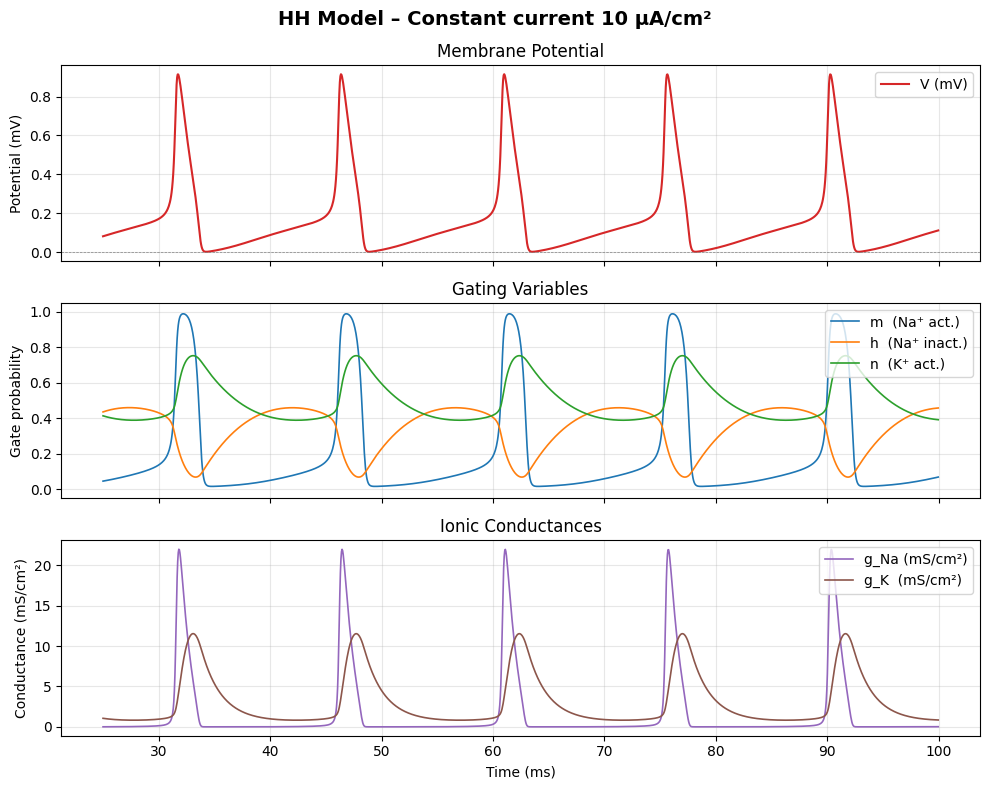

In [29]:
# ---------------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------------

# --- Example 1: constant supra-threshold step current ---
t, V, m, h, n = simulate_hh(t_span=(0, 100), dt=0.05, I_ext=10.0)
v_min, v_max = min(V), max(V)
print(v_min, v_max)
V_scaled = (V - v_min) / (v_max - v_min)
print(len(t))
skip_first = 500
V_scaled = V_scaled[skip_first:]
m = m[skip_first:]
h = h[skip_first:]
n = n[skip_first:]
t = t[skip_first:]
fig = plot_hh(t, V_scaled, m, h, n, title="HH Model – Constant current 10 µA/cm²")
plt.savefig("hh_constant_current.png", dpi=150)
plt.show()

/Users/winkt0/projects/alrnn-marl/dataset.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.X = torch.tensor(data, dtype=torch.float32)


torch.Size([1500, 4])
tensor([[0.0813, 0.0461, 0.4358, 0.4138],
        [0.0822, 0.0467, 0.4369, 0.4129],
        [0.0831, 0.0473, 0.4379, 0.4119],
        ...,
        [0.1097, 0.0676, 0.4574, 0.3926],
        [0.1105, 0.0683, 0.4577, 0.3922],
        [0.1113, 0.0690, 0.4580, 0.3919]], dtype=torch.float64)
torch.Size([1500, 4])
TrainingHodgkin-Huxley ALRNN


Training Progress: 100%|████████| 200/200 [18:21<00:00,  5.51s/it, loss=0.00309]


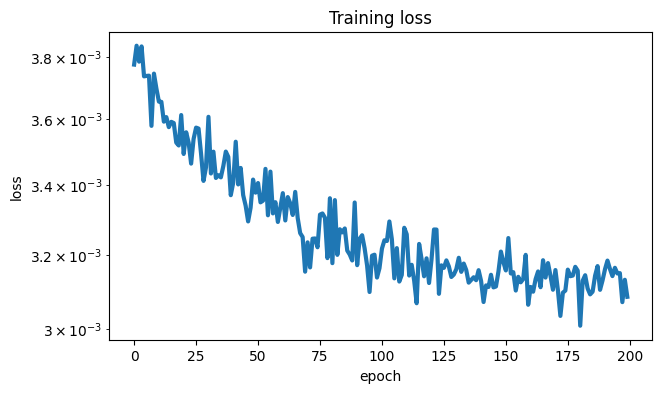

Saving trained model models/2026-06-09 10:42:47Hodgkin-Huxley ALRNN
torch.Size([1500, 12])


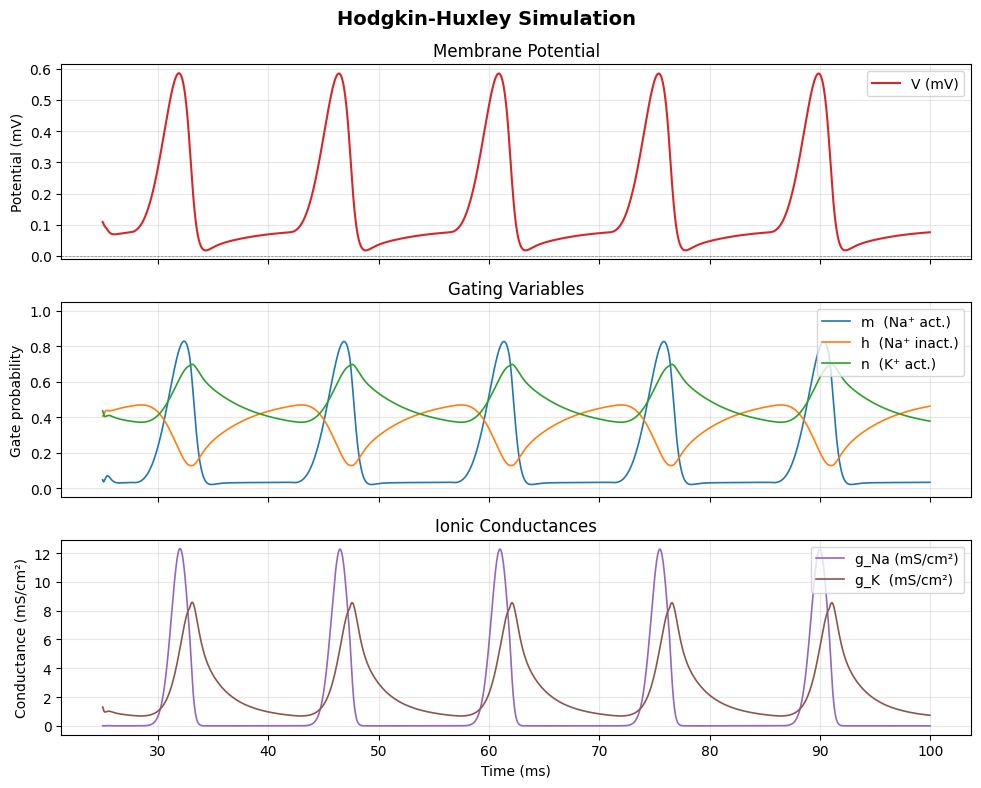

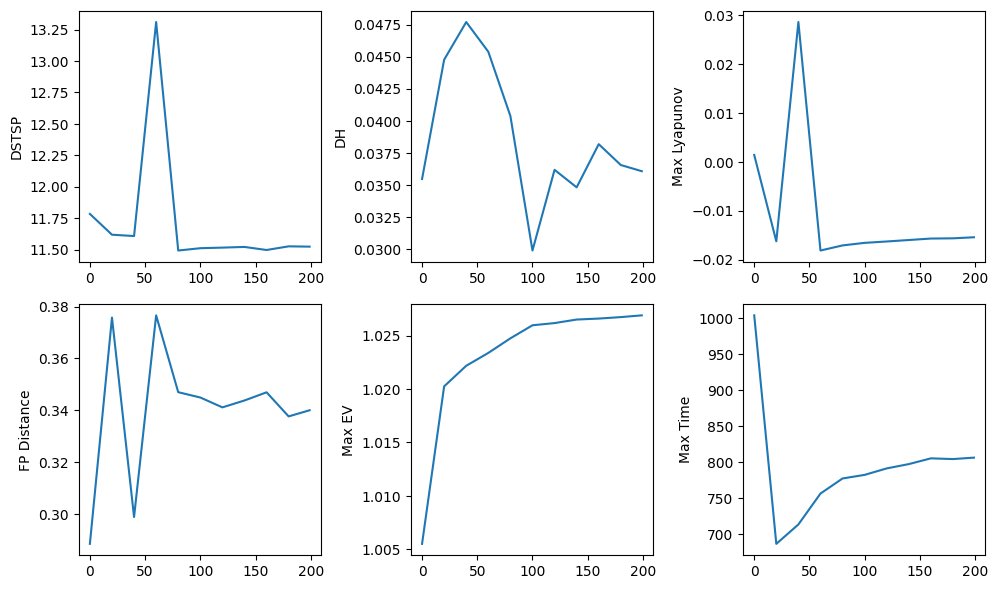

In [33]:
#model = create_model(N=4, M=12, P=2)
trajectory = torch.tensor([V_scaled, m, h, n]).permute(1, 0)
print(trajectory.shape)
free_sequence, log_path = train_and_save_model(model, trajectory)
print(free_sequence.shape)
plot_hh(t, free_sequence[:,0], free_sequence[:,1], free_sequence[:,2], free_sequence[:,3])
visualize_training(log_path)

In [ ]:
# --- Example 2: brief current pulse ---
def pulse(t):
    return 20.0 if 5.0 <= t <= 6.0 else 0.0

t, V, m, h, n = simulate_hh(t_span=(0, 50), I_ext=pulse)
fig = plot_hh(t, V, m, h, n, title="HH Model – 1 ms current pulse")
plt.savefig("hh_pulse.png", dpi=150)
plt.show()

# --- Example 3: ramp current – shows threshold behaviour ---
def ramp(t):
    return 0.5 * t   # increases 0.5 µA/cm² per ms

t, V, m, h, n = simulate_hh(t_span=(0, 50), I_ext=ramp)
fig = plot_hh(t, V, m, h, n, title="HH Model – Ramp current (threshold demo)")
plt.savefig("hh_ramp.png", dpi=150)
plt.show()